In [42]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('house_prices_dataset.csv')
df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,zipcode,lat,long,price
0,3,1,2803,1153,1,0,0,3,9,2003,0,98001,47.660671,-121.785347,835016.23
1,5,3,783,9762,1,0,2,4,4,2019,0,98003,47.681937,-122.151515,326073.09
2,3,3,3412,2842,2,0,3,4,9,1961,1962,98002,47.182798,-121.792089,1025404.09
3,2,3,2222,9020,2,1,2,4,4,2008,1962,98004,47.440995,-121.871224,758764.79
4,4,1,4713,1584,2,0,3,4,5,1987,0,98005,47.701306,-122.416623,1314784.23


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bedrooms        1000 non-null   int64  
 1   bathrooms       1000 non-null   int64  
 2   sqft_living     1000 non-null   int64  
 3   sqft_lot        1000 non-null   int64  
 4   floors          1000 non-null   int64  
 5   waterfront      1000 non-null   int64  
 6   view            1000 non-null   int64  
 7   condition       1000 non-null   int64  
 8   grade           1000 non-null   int64  
 9   year_built      1000 non-null   int64  
 10  year_renovated  1000 non-null   int64  
 11  zipcode         1000 non-null   int64  
 12  lat             1000 non-null   float64
 13  long            1000 non-null   float64
 14  price           1000 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 117.3 KB


In [48]:
df.isnull().sum()

bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
year_built        0
year_renovated    0
zipcode           0
lat               0
long              0
price             0
dtype: int64

In [ ]:
df.drop(["lat","long","zipcode"], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bedrooms        1000 non-null   int64  
 1   bathrooms       1000 non-null   int64  
 2   sqft_living     1000 non-null   int64  
 3   sqft_lot        1000 non-null   int64  
 4   floors          1000 non-null   int64  
 5   waterfront      1000 non-null   int64  
 6   view            1000 non-null   int64  
 7   condition       1000 non-null   int64  
 8   grade           1000 non-null   int64  
 9   year_built      1000 non-null   int64  
 10  year_renovated  1000 non-null   int64  
 11  zipcode         1000 non-null   int64  
 12  lat             1000 non-null   float64
 13  long            1000 non-null   float64
 14  price           1000 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 117.3 KB


In [ ]:
# ols model
formular='price~bedrooms+bathrooms+sqft_living+sqft_lot+floors+year_built+year_renovated+C(grade)+C(condition)+C(waterfront)+C(view)'
lm=ols(formular,df).fit()
table=sm.stats.anova_lm(lm,typ=2)
table


,sum_sq,df,F,PR(>F)
C(grade),7.624866e+11,11.0,183.316235,2.858685e-228
C(condition),2.041546e+11,4.0,134.977239,9.551189e-92
C(waterfront),9.166195e+11,1.0,2424.099877,2.058608e-266
C(view),1.776019e+10,3.0,15.656251,5.974182e-10
bedrooms,4.708068e+11,1.0,1245.099809,2.690992e-176
bathrooms,6.161723e+10,1.0,162.953472,1.290603e-34
sqft_living,1.015938e+14,1.0,268675.916515,0.000000e+00
sqft_lot,1.959280e+09,1.0,5.181529,2.304476e-02
floors,4.142126e+07,1.0,0.109543,7.407363e-01
year_built,5.214565e+06,1.0,0.013790,9.065413e-01


In [8]:
# Correlation with price
corr_matrix = df.corr(numeric_only=True)
price_corr = corr_matrix["price"].sort_values(ascending=False)
print("Correlation of Features with Price:")
print(price_corr)

Correlation of Features with Price:
price             1.000000
sqft_living       0.986325
grade             0.087347
waterfront        0.080397
view              0.065690
condition         0.064545
bathrooms         0.060793
bedrooms          0.051959
year_built        0.036437
floors            0.015929
zipcode           0.009141
long             -0.016663
sqft_lot         -0.020945
year_renovated   -0.032089
lat              -0.032323
Name: price, dtype: float64


In [19]:
from scipy import stats
x = df["sqft_living"]
y = df["price"]
slope, intercept, r, p, std_err = stats.linregress(x,y)
print(r)

0.9863246630954574


In [27]:
# Define features and target variables
X=df[["bedrooms","bathrooms","sqft_living","sqft_lot","floors","waterfront","view","condition","grade","year_built","year_renovated","zipcode","lat","long"]]  # features, all columns except price,depenent variable
y = df['price'] # target column,independent variable

In [28]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)

In [33]:
#  train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [38]:
# Make predictions
y_pred = model.predict(X_test)

In [40]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error:{mae}")

Mean Absolute Error:16107.781093101721


In [45]:
df["price"].head()

0     835016.23
1     326073.09
2    1025404.09
3     758764.79
4    1314784.23
Name: price, dtype: float64

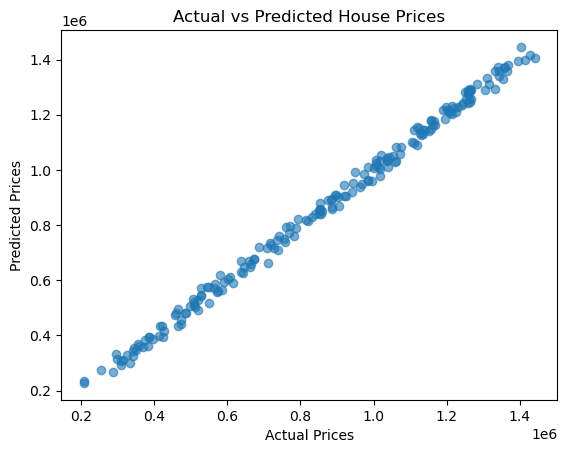

In [43]:
# Visualize actual vs predicted prices
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [47]:
# build the ols model
model = sm.OLS(y, X).fit()

# Display the full summary
print(model.summary())


                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.499e+05
Date:                Mon, 27 Oct 2025   Prob (F-statistic):                        0.00
Time:                        01:47:03   Log-Likelihood:                         -11294.
No. Observations:                1000   AIC:                                  2.262e+04
Df Residuals:                     986   BIC:                                  2.269e+04
Df Model:                          14                                                  
Covariance Type:            nonrobust                                                  
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------